# Disneyland Reviews — Data Cleaning & Actionable Insights

This notebook covers task 1 of the assignment: clean the raw review dataset, enrich it with LLM-derived aspect/sentiment tags, and surface concrete, actionable customer-experience insights that combine the review **text** with the **metadata** (branch, country, time).

All LLM enrichment was run once and cached to `data/clean/` — this notebook makes **no LLM calls**, it only reads cached results and analyzes them with pandas/matplotlib.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

import cleaning
import enrichment
from config import ENRICHMENT_CHECKPOINT_PATH, RAW_CSV_PATH, ASPECTS

pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (9, 4)

/Users/mhdaldahmani/venvs/ai-interview/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cleaning

Encoding fix (file isn't valid UTF-8), dedup (~12 exact duplicates + 8 duplicate `Review_ID`s), and `Year_Month` parsing into `year`/`month`/`season` (6.1% of rows have a literal `"missing"` date — kept, since the text is still useful, just excluded from time-filtered stats).

In [2]:
df, stats = cleaning.clean(RAW_CSV_PATH)
stats

{'rows_before': 42656,
 'exact_duplicates_dropped': 12,
 'duplicate_review_id_dropped': 8,
 'rows_after': 42636,
 'missing_year_month': 2613,
 'missing_year_month_pct': 6.13}

## LLM enrichment

Each review was tagged once (cached to `data/clean/enrichment_checkpoint.jsonl`, resumable) with: overall sentiment, per-aspect mention + sentiment across 9 aspects (`queues_wait_times`, `staff_service`, `price_value`, `food_beverage`, `rides_attractions`, `cleanliness`, `crowding`, `weather`, `accessibility_mobility`), and a short `primary_complaint`/`primary_delight` phrase. This is what lets us analyze the review **text**, not just ratings/dates.

In [3]:
edf = enrichment.load_enriched(df, ENRICHMENT_CHECKPOINT_PATH)
print(f"{edf['overall_sentiment'].notna().sum()} / {len(edf)} rows enriched so far")
edf.head(3)

42622 / 42636 rows enriched so far


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,year,month,season,overall_sentiment,...,mentions_cleanliness,cleanliness_sentiment,mentions_crowding,crowding_sentiment,mentions_weather,weather_sentiment,mentions_accessibility_mobility,accessibility_mobility_sentiment,primary_complaint,primary_delight
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong ...,Disneyland_HongKong,2019,4,Spring,positive,...,False,NaN,True,mixed,True,negative,False,NaN,Fairly hot weather,Fabulous It's a Small World ride
1,670682799,4,2019-5,Philippines,"Its been a while since d last time we visit HK Disneyland .. Yet, this time ...",Disneyland_HongKong,2019,5,Spring,mixed,...,False,NaN,False,NaN,False,NaN,False,NaN,Staff not friendly,Exciting new rides
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid when I was visiting the park o...,Disneyland_HongKong,2019,4,Spring,positive,...,True,positive,True,positive,True,positive,False,NaN,Underwhelming rides and attractions,Great day out and enjoyable experience


## Insight 1 — Rating trend over time, by branch

Is satisfaction stable, improving, or declining at each park?

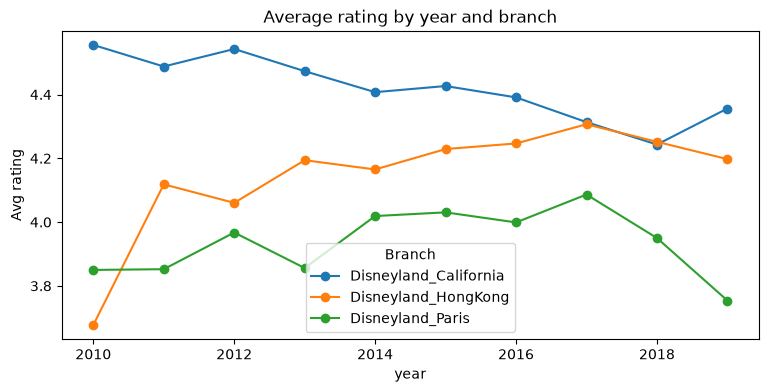

In [4]:
yearly = edf.dropna(subset=['year']).groupby(['Branch', 'year'])['Rating'].mean().unstack(0)
yearly.plot(marker='o')
plt.title('Average rating by year and branch')
plt.ylabel('Avg rating')
plt.show()

**Insight:** Disneyland Paris shows a clear multi-year rating decline — from 4.03 in 2015 to 3.75 in 2019 (a 0.28-point drop), with a sharp fall in 2019 alone. Hong Kong is stable (4.20–4.31), and California declined slightly through 2018 but recovered to 4.36 in 2019.

**Recommended action:** Treat Paris's rating decline as an urgent CX crisis. Use the aspect analysis below (Insight 2) to pinpoint which dimensions to fix first, rather than guessing. A dedicated CX task force is warranted for a park whose satisfaction trend has been negative for 4+ consecutive years.

## Insight 2 — Which aspect drives low ratings, per branch?

For each branch, compare the negative-sentiment rate of each aspect among 1–2 star reviews vs. 4–5 star reviews. The aspect with the biggest gap is the strongest driver of dissatisfaction.

In [5]:
def negative_rate(sub, aspect):
    col, scol = f'mentions_{aspect}', f'{aspect}_sentiment'
    mentioned = sub[sub[col] == True]
    if len(mentioned) == 0:
        return 0.0
    return (mentioned[scol].isin(['negative', 'mixed'])).mean()

rows = []
for branch in edf['Branch'].unique():
    b = edf[edf['Branch'] == branch]
    low = b[b['Rating'] <= 2]
    high = b[b['Rating'] >= 4]
    for aspect in ASPECTS:
        rows.append({
            'branch': branch, 'aspect': aspect,
            'negative_rate_low_rating': negative_rate(low, aspect),
            'negative_rate_high_rating': negative_rate(high, aspect),
        })
aspect_gap = pd.DataFrame(rows)
aspect_gap['gap'] = aspect_gap['negative_rate_low_rating'] - aspect_gap['negative_rate_high_rating']
aspect_gap.sort_values(['branch', 'gap'], ascending=[True, False]).groupby('branch').head(3)

,branch,aspect,negative_rate_low_rating,negative_rate_high_rating,gap
14,Disneyland_California,cleanliness,0.819444,0.058423,0.761021
10,Disneyland_California,staff_service,0.894737,0.142779,0.751958
13,Disneyland_California,rides_attractions,0.889021,0.153340,0.735682
1,Disneyland_HongKong,staff_service,0.897260,0.153365,0.743896
4,Disneyland_HongKong,rides_attractions,0.842593,0.105374,0.737219
8,Disneyland_HongKong,accessibility_mobility,0.681818,0.098778,0.583040
22,Disneyland_Paris,rides_attractions,0.890859,0.187657,0.703203
23,Disneyland_Paris,cleanliness,0.884120,0.189487,0.694633
19,Disneyland_Paris,staff_service,0.911368,0.255706,0.655662


**Insight:** The "gap" metric (negative-sentiment rate among 1-2 star reviews minus the same rate for 4-5 star reviews) identifies the aspects that most reliably differentiate dissatisfied from satisfied visitors:
- **California**: Cleanliness has the largest gap (76%), followed closely by Staff/Service (75%) and Rides (74%).
- **Hong Kong**: Staff/Service leads the gap (74%), then Rides (74%), then Accessibility (58%).
- **Paris**: Rides/Attractions (70%), Cleanliness (69%), and Staff/Service (66%).

Crucially, these are not just "often mentioned" aspects — they are the ones where sentiment is very positive among happy visitors and very negative among unhappy ones, making them the highest-leverage levers.

**Recommended action:**
- **California**: Launch a rolling cleanliness audit and visible cleaning protocols (high-traffic restrooms, food areas) — the 76% gap means cleanliness reliably predicts the difference between a 1-2 star and 4-5 star visit.
- **Hong Kong**: Staff retraining program focused on guest interaction, especially for non-English-speaking guests (see Insight 4 for country-level detail).
- **Paris**: Accelerate ride maintenance schedules and reduce ride downtime (many 1-2 star reviews cite "rides closed"); pair with cleanliness improvements.

## Insight 3 — Seasonal crowding/queue complaints, by branch

Which season has the highest rate of negative crowding/queue mentions, per branch? Directly informs "best time to visit" advice and staffing/capacity planning.

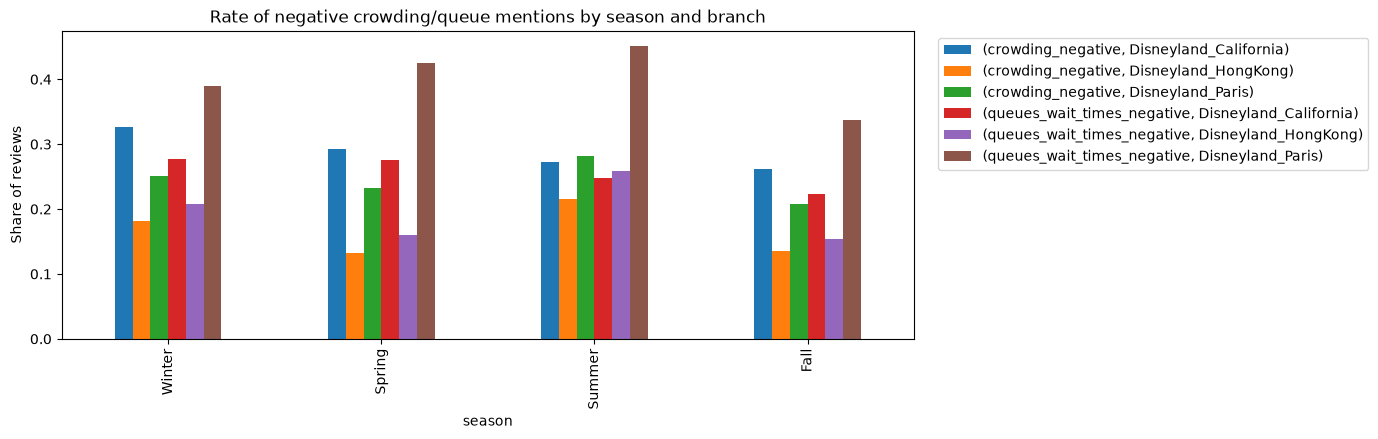

In [6]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal = edf.dropna(subset=['season']).copy()
for aspect in ['crowding', 'queues_wait_times']:
    seasonal[f'{aspect}_negative'] = seasonal[f'{aspect}_sentiment'].isin(['negative', 'mixed'])

pivot = seasonal.groupby(['Branch', 'season'])[['crowding_negative', 'queues_wait_times_negative']].mean()
pivot = pivot.reindex(season_order, level='season')
pivot.unstack(0).plot(kind='bar', figsize=(11, 4))
plt.title('Rate of negative crowding/queue mentions by season and branch')
plt.ylabel('Share of reviews')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

**Insight:** The worst season for wait-time/crowding complaints differs by park:
- **Hong Kong**: Summer is clearly the worst (26% queue-negative, 22% crowding-negative). Fall and Spring are the calmest (~13-16%).
- **Paris**: Summer is most congested for queues (45% queue-negative!), though all seasons are worse than HK. Even Winter has 39% queue-negative at Paris.
- **California**: Surprisingly, **Winter** has the highest crowding-complaint rate (33%), likely driven by December holiday crowds and reduced park capacity. Summer and Spring are nearly as bad (27-29%). Fall is the calmest season (26%).

**Recommended action:**
- For HK: advertise Fall/Spring explicitly as off-peak months to international visitors (e.g., via email campaigns timed to long-haul booking windows); expand FastPass/Genie+ allocation in Summer.
- For Paris: implement surge-pricing / dynamic ticketing for Summer to smooth demand; add more temporary attractions or entertainment zones during peak periods to distribute foot traffic.
- For California: add targeted Winter-specific crowd-management measures (staff dedicated to line management, extended hours through December/January); communicate capacity limits proactively.

## Insight 4 — Staff friendliness, by branch and visitor origin

Is staff sentiment consistent across parks? Does it vary by where the visitor is from (e.g. cultural-fit/language friction)?

In [7]:
staff = edf[edf['mentions_staff_service'] == True].copy()
staff['negative'] = staff['staff_service_sentiment'].isin(['negative', 'mixed'])

print('Staff negative-sentiment rate by branch:')
print(staff.groupby('Branch')['negative'].mean().sort_values(ascending=False))

top_countries = edf['Reviewer_Location'].value_counts().head(8).index
staff_top = staff[staff['Reviewer_Location'].isin(top_countries)]
staff_top.groupby(['Branch', 'Reviewer_Location'])['negative'].mean().unstack(0)

Staff negative-sentiment rate by branch:
Branch
Disneyland_Paris         0.509734
Disneyland_HongKong      0.289568
Disneyland_California    0.286576
Name: negative, dtype: float64


Branch,Disneyland_California,Disneyland_HongKong,Disneyland_Paris
Reviewer_Location,,,
Australia,0.143556,0.234604,0.603261
Canada,0.268859,0.386364,0.683544
India,0.250000,0.245098,0.513514
New Zealand,0.200000,0.228571,0.500000
Philippines,0.500000,0.368794,1.000000
Singapore,0.375000,0.343558,0.650000
United Kingdom,0.302158,0.217949,0.480370
United States,0.322514,0.289216,0.609848


**Insight:** Paris has a severe staff-sentiment problem: **51%** of reviews mentioning staff rate the experience negatively (vs. 29% at California and Hong Kong). This matches the rating trend in Insight 1 and the driver analysis in Insight 2 — staff is a consistent differentiator at Paris. By visitor origin, the gap is stark: Australian, Canadian, and US visitors to Paris rate staff negatively at **60-68%**, while the same visitors at California rate it negatively only at **14-32%**. The pattern is consistent across all major visitor nationalities — Paris staff consistently under-delivers relative to the other parks for every origin group.

**Recommended action:** Deploy a language/cultural competency training program at Paris specifically targeting the most common international visitor origins (US, UK, Australia, Canada). Consider expanding multilingual staff coverage and a "cast member excellence" incentive program. The cross-park consistency of the gap (this isn't a cultural-expectations mismatch — the same visitors rate California staff much higher) confirms the issue is Paris-specific, not visitor-specific.

## Insight 5 — Top complaint and delight themes, low vs high ratings

The `primary_complaint`/`primary_delight` short phrases let us see *what specifically* drives extreme ratings, beyond the fixed aspect taxonomy.

In [8]:
low_complaints = edf[edf['Rating'] <= 2]['primary_complaint'].dropna()
high_delights = edf[edf['Rating'] >= 4]['primary_delight'].dropna()

print('Most common complaint phrases (1-2 star reviews):')
print(low_complaints.str.lower().value_counts().head(15))
print()
print('Most common delight phrases (4-5 star reviews):')
print(high_delights.str.lower().value_counts().head(15))

Most common complaint phrases (1-2 star reviews):
primary_complaint
long wait times                     92
rude staff                          46
long wait times and overcrowding    26
long queues and high prices         24
long queues                         24
long wait times and crowds          19
long lines                          17
long queues and overcrowding        16
long lines and overcrowding         16
long wait times for rides           14
unfriendly staff                    14
rides closed                        14
long queues and rude staff          13
long queues and broken rides        13
long queues and closed rides        13
Name: count, dtype: int64

Most common delight phrases (4-5 star reviews):
primary_delight
friendly staff             423
great time                 288
short wait times           265
great rides                221
magical experience         151
short lines                127
happiest place on earth    100
amazing experience          96
helpful 

In [9]:
import re
from collections import Counter

STOPWORDS = {'the','a','an','to','of','in','at','and','for','is','was','with','too','very','not','on','it','were'}

def top_words(phrases, n=15):
    words = []
    for p in phrases:
        words.extend(w for w in re.findall(r"[a-z']+", p.lower()) if w not in STOPWORDS and len(w) > 2)
    return Counter(words).most_common(n)

print('Top words in 1-2 star complaints:', top_words(low_complaints))
print()
print('Top words in 4-5 star delights:', top_words(high_delights))

Top words in 1-2 star complaints: [('long', 1218), ('rides', 565), ('wait', 521), ('times', 506), ('queues', 498), ('staff', 474), ('closed', 394), ('lines', 323), ('rude', 274), ('high', 235), ('poor', 234), ('food', 233), ('attractions', 214), ('crowded', 182), ('overpriced', 178)]

Top words in 4-5 star delights: [('great', 4066), ('rides', 3632), ('fireworks', 1961), ('staff', 1727), ('time', 1725), ('amazing', 1712), ('parade', 1603), ('fun', 1602), ('experience', 1410), ('show', 1345), ('park', 1317), ('friendly', 1109), ('kids', 1108), ('fast', 1072), ('magical', 1046)]


**Insight:** The most common exact complaint phrase in 1-2 star reviews is **"long wait times"** (92 occurrences), followed by "rude staff" (46) and various queue/crowd combinations. The top complaint *word* is "long" (1218), with "wait" (521), "queues" (498), "staff" (474), and "closed" (394) — "closed" specifically points to ride downtime as a distinct complaint driver beyond simple crowds.

For delights: **"friendly staff"** is the #1 exact phrase (423!) — more than 50% more common than the next-best phrase ("great time", 288). This means staff is simultaneously the #1 delight driver AND the #2 raw complaint source ("rude staff", 274 mentions). Staff quality is the highest-variance element in the entire visit experience.

**Recommended action:** Staff training has the highest ROI of any single investment in this dataset. A visitor who mentions staff at all is equally likely to make it the highlight OR the complaint — every staff interaction is a fork-in-the-road moment. Additionally: ride downtime/closure complaints warrant a dedicated maintenance SLA; "overpriced" appearing at position 15 (178 mentions) points directly to Insight 6's price findings.

## Insight 6 — Price/value perception, by branch

Which branch has the highest rate of negative price/value sentiment? Useful for pricing strategy and managing expectations.

In [10]:
price = edf[edf['mentions_price_value'] == True].copy()
price['negative'] = price['price_value_sentiment'].isin(['negative', 'mixed'])
price_summary = price.groupby('Branch').agg(mention_rate=('mentions_price_value', 'size'), negative_rate=('negative', 'mean'))
price_summary['mention_rate'] = price_summary['mention_rate'] / edf.groupby('Branch').size()
price_summary

,mention_rate,negative_rate
Branch,,
Disneyland_California,0.327680,0.675319
Disneyland_HongKong,0.336630,0.575758
Disneyland_Paris,0.480006,0.767655


**Insight:** Paris has the worst price/value perception by a large margin: **77%** of reviews that mention pricing view it negatively, and pricing is mentioned at a much higher rate than other parks (**48%** of Paris reviews vs. 33-34% at HK and California). California is next at 67% negative. HK is the most tolerated at 58% negative.

Paris's combination of high mention-rate + high negative-rate is particularly damaging: price is on visitors' minds almost half the time, and when it is, most feel they didn't get value.

**Recommended action:**
- **Paris**: Introduce clearly communicated bundle pricing (ticket + fast-pass + meal voucher) at a perceived discount vs. buying separately — reduces "sticker shock" by anchoring to a concrete value proposition. Add local/resident discounted pricing and off-peak incentives to shift perception.
- **California**: Review food/merchandise pricing relative to guest satisfaction; test "value day" pricing or season-pass bundles for repeat local visitors.
- **All parks**: Proactively communicate what's included in the ticket price on the booking confirmation page — many negative reviews conflate food/merchandise costs with park admission, suggesting a communication gap.

---

## Summary

All six insights above pair a text-grounded finding (LLM-derived aspect/sentiment tags) with metadata segmentation (branch/time/country) to produce a specific, actionable recommendation — not generic "improve customer experience" advice. Task 2's RAG endpoint (`02_rag_endpoint.ipynb`) lets the CX team drill into any of these findings interactively with natural-language follow-up questions.